In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# ※ naver open API를 활용하여 네이버지식인 '전주여행'과 '경주여행'을 검색 -> 명사만 추출(re?) -> 빈도분석(DataFrame) -> 빈도 시각화(워드클라우드, Text) -> Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title+ ' ' +description

In [2]:
# 함수 작성
def get_naver_kin(keyword, display):
    from dotenv import load_dotenv
    import os
    import requests
    import json
    import pandas as pd

    load_dotenv()
    client_id = os.getenv('Client_ID')
    client_secret = os.getenv('Client_Secret')

    url = f'https://openapi.naver.com/v1/search/kin.json?query={keyword}&display={display}'
    headers = {'X-Naver-Client-Id':client_id,
              'X-Naver-Client-Secret':client_secret}
    response = requests.get(url, headers=headers)
#     print(response.status_code)
    items = json.loads(response.text)['items'] # 방법1과 방법2
#     print(items)

    items_list = []
    for item in items:
        items_list.append([
            item.get('title').replace('<b>','').replace('</b>',''), # item['title']
            item.get('link'),
            item.get('description').replace('<b>','').replace('</b>','')
        ])
    return pd.DataFrame(items_list, columns=['title', 'link', 'description'])

In [13]:
display = 5
df_jj = get_naver_kin('전주여행', display)
df_kj = get_naver_kin('경주여행', display)

title_Des_jj = [df_jj['title'][i]+' '+df_jj['description'][i] for i in range(len(df_jj))]
title_Des_kj = [df_kj['title'][i]+' '+df_kj['description'][i] for i in range(len(df_kj))]

from konlpy.tag import Kkma
kkma = Kkma()
j_kins = []
k_kins = []
for i in range(display):
    jnoun_list = kkma.nouns(title_Des_jj[i])
    knoun_list = kkma.nouns(title_Des_kj[i])
    불용어 = {'여행', '경주', '전주'}
    jnoun_list = [word for word in jnoun_list if word not in 불용어]
    knoun_list = [word for word in knoun_list if word not in 불용어]
    j_kins.append(' '.join(jnoun_list))
    k_kins.append(' '.join(knoun_list))

jj_nouns = ' '.join(j_kins)
kj_nouns = ' '.join(k_kins)

In [19]:
jj_nouns

'곳 추천 추억 7080 다양 체험 7080감성 감 성 추억여행 테마 테마박물관 박물관 유익 시간 2 전 전북 북 전북투어패스 투어 패스 통합 통합이용권 이용권 전북핫플 핫 플 여행지 카페 카페이용추가 이용 추가 전주여행필수 필수 편안 날 감사 전주여행 사람 호텔 가격 음 2 2박3일 박 3 일 얼마 얼마정도 정도 맛 맛집 집 거 카페 추천 안녕 안녕하세 하세 계획 중이 한옥 한옥마을 마을 근처 1 1박 박 2 2일 일 관련 질문 계획 선택 한옥 한옥마을 마을 자연 자연경관 경관 음식 동네 시간 수 거 우선 근처 장소 중 중2 2 여 여학생 학생 친구 전주여행 안녕 15 15살 살 둘 가기 어디 ㅜ 저희 둘 일본 애 니 오타쿠 곳 발 부 부모닝 모닝 전주여행 부모님 데 명소 식당 추천 한옥 한옥마을 마을 유명 완산 완산구 구 덕진 덕진구 추억 장소'

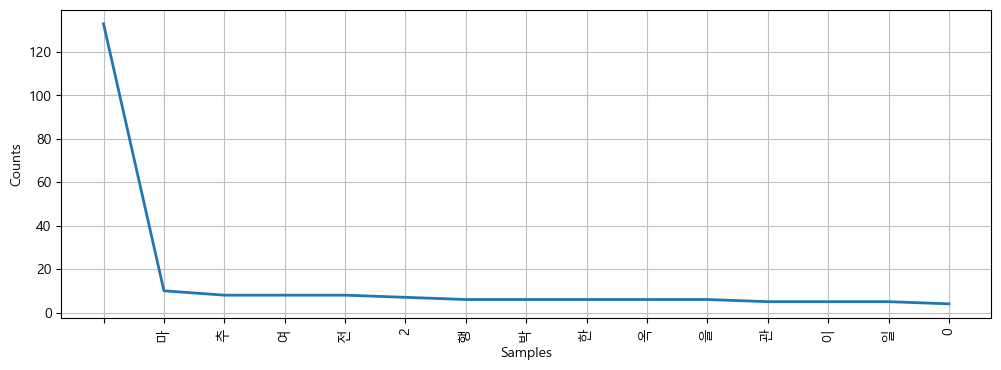

In [17]:
import nltk
data_text = nltk.Text(jj_nouns)
plt.figure(figsize=(12, 4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

In [23]:
data_text.vocab().most_common(20)

[(' ', 118),
 ('일', 12),
 ('박', 7),
 ('2', 7),
 ('정', 7),
 ('경', 6),
 ('행', 6),
 ('1', 6),
 ('월', 6),
 ('3', 5),
 ('스', 4),
 ('주', 4),
 ('중', 4),
 ('이', 4),
 ('0', 4),
 ('5', 4),
 ('버', 3),
 ('여', 3),
 ('무', 3),
 ('휴', 3)]

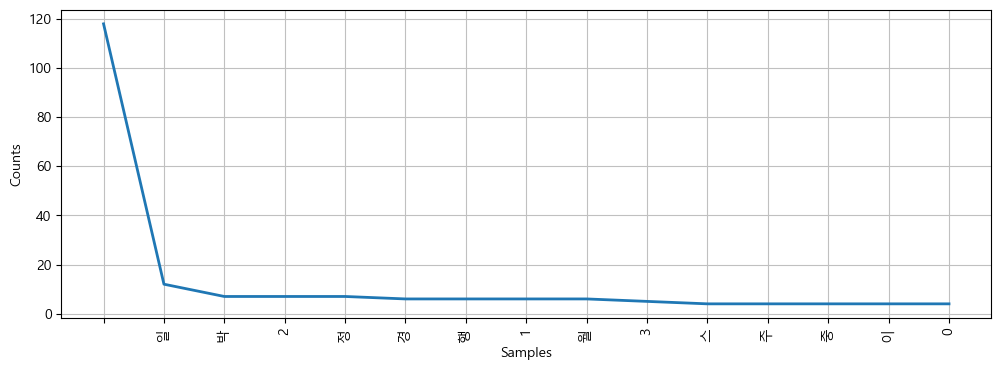

In [21]:
data_text = nltk.Text(kj_nouns)
plt.figure(figsize=(12, 4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

In [24]:
data_text.vocab().most_common(20)

[(' ', 118),
 ('일', 12),
 ('박', 7),
 ('2', 7),
 ('정', 7),
 ('경', 6),
 ('행', 6),
 ('1', 6),
 ('월', 6),
 ('3', 5),
 ('스', 4),
 ('주', 4),
 ('중', 4),
 ('이', 4),
 ('0', 4),
 ('5', 4),
 ('버', 3),
 ('여', 3),
 ('무', 3),
 ('휴', 3)]

<function matplotlib.pyplot.show(close=None, block=None)>

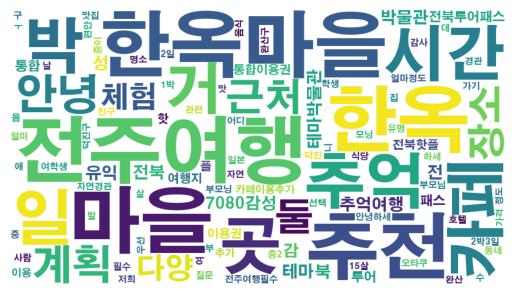

In [15]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordCl = WordCloud(
                font_path='C:/Windows/Fonts/H2GTRE.TTF',
                width=900, # 생성될 이미지 가로길이
                height=500,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.5,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
)
wordCl.generate(jj_nouns)
plt.imshow(wordCl)
plt.axis('off')
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

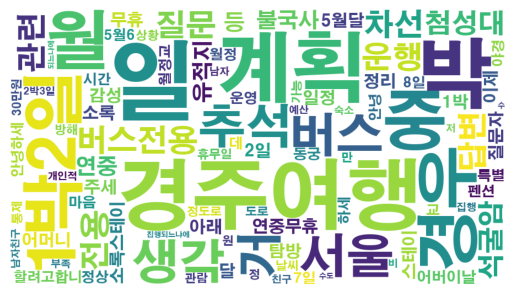

In [16]:
wordCl.generate(kj_nouns)
plt.imshow(wordCl)
plt.axis('off')
plt.show